In [2]:
import numpy as np

signal = np.ones((196,1))

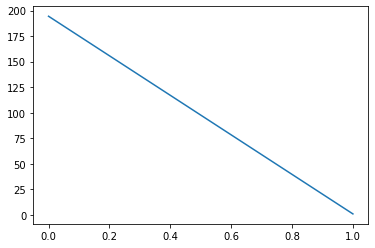

In [3]:
import matplotlib.pyplot as plt
plt.plot(np.random.normal((196,1)))

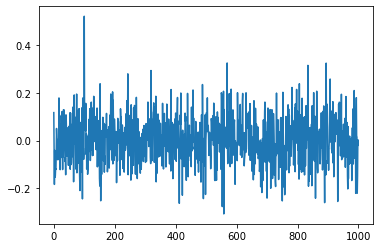

In [4]:
mu, sigma = 0, 0.1 # mean and standard deviation
s = np.random.normal(mu, sigma, 1000)
plt.plot(s)

SNR:  0.08730188192172879
SNR:  2.880357737851248


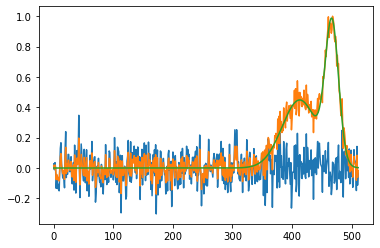

In [147]:
import random
def get_gaussian(mu,sigma):
    def gaussian(x):
        a = -1/2 * (x-mu)**2/sigma**2
        return np.exp(a)/(sigma*np.sqrt(2*np.pi))
    return np.vectorize(gaussian)
def get_ReLU(freq):
    def ReLU(x):
        return abs((x) * (x > 1-freq))
    return ReLU
relu1 = get_ReLU(0.2)
relu2 = get_ReLU(0.3)

min_val = 20
max_val = 480
target_snr = 5
mu1 = random.randint(min_val,max_val)
sigma1 = random.randint(10,30)
mu2 = random.randint(min_val,max_val)
sigma2 = random.randint(10,30)
rng = np.random.default_rng()
weight1 = relu1(rng.random())
weight2 = relu2(rng.random())
pulse = [get_gaussian(mu1,sigma1),get_gaussian(mu1+sigma1,sigma1),get_gaussian(mu2,sigma2)]

mu, sigma = 0, 0.1 # mean and standard deviation
s = np.random.normal(mu, sigma, 512)
a = np.linspace(0,500,512)
wave = pulse[0](a) - pulse[1](a)*weight1 + pulse[2](a)*weight2
snr = max(wave)/max(s)
print("SNR: ", max(wave)/max(s))
weight = target_snr/snr
res = wave*weight + s
clean = wave*weight
normalization_constant =  max(max(res),max(clean))
res = res/normalization_constant
clean = wave*weight/normalization_constant
print("SNR: ", max(res)/max(s))
plt.plot(s)
plt.plot(res)
plt.plot(clean)

In [106]:
# Source - https://stackoverflow.com/a/63177397
# Posted by JuliettVictor, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-09, License - CC BY-SA 4.0

def signaltonoise(a, axis=0, ddof=0):
    a = np.asanyarray(a)
    m = a.mean(axis)
    sd = a.std(axis=axis, ddof=ddof)
    return np.where(sd == 0, 0, m/sd)


signaltonoise(res)

array(0.01371851)

In [80]:
import os
try:
    os.chdir("/home/maniacalm/bin/VQVAE_studies")
except FileNotFoundError:
    print("Either filepath is wrong or this is ran on another computer")

In [11]:
import numpy as np
import matplotlib.pyplot as plt

a=np.load("snb-Z-signal-0.npy",allow_pickle=True)
c=np.load("snb-Z-clnsig-0.npy",allow_pickle=True)
nwf=a.size
ntcks=len(a[0])-54
train_noise = []
train_signal = []
for j in range(nwf-50):
    ya=[]
    yc=[]
    j=0
    for i in range(0,ntcks):
        lab='tck_'+str(i)
        ya.append(a[j][lab])
        yc.append(c[j][lab])
    train_noise.append(ya)
    train_signal.append(yc)
test_noise = []
test_signal = []
for j in range(nwf-50,nwf-1):
    ya=[]
    yc=[]
    j=0
    for i in range(0,ntcks):
        lab='tck_'+str(i)
        ya.append(a[j][lab])
        yc.append(c[j][lab])
    test_noise.append(ya)
    test_signal.append(yc)
train_noise_c = np.reshape(np.array(train_noise), (-1, 1,512))
train_signal_c = np.reshape(np.array(train_signal), (-1, 1,512))
test_noise_c = np.reshape(np.array(test_noise), (-1, 1,512))
test_signal_c = np.reshape(np.array(test_signal), (-1, 1,512))
print(len(train_noise_c))
print(train_noise_c.shape)

196
(196, 1, 512)


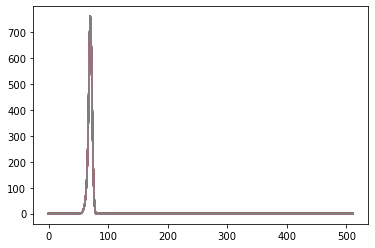

In [19]:

for i in range(len(test_signal)-1):
    plt.plot(test_signal[i])